# T10 - Particiones en árboles de clasificación

***Nombre:** Valeria Estefanía Milke Loera

**Expediente:** 739228

**Fechaa:** 11-05-2026
_________

## 1. Definición de conceptos

#### 1.1 Pureza del nodo

En árboles de clasificación, la pureza del nodo se refiere al grado en que las observaciones dentro de un nodo pertenecen a una sola clase. Un nodo es puro cuando la mayoría o todas las observaciones pertenecen a la misma categoría. Es decir, cuando un nodo tiene observaciones mezcladas de distintas clases, la impureza es mayor. Los criterios de decisión como Gini, Entropía y Log Loss buscan generar particiones que aumenten la pureza de los nodos.

#### 1.2 Índice Gini 

Es una medida de impureza utilizada en árboles de clasificación para evaluar la calidad de una partición. De acuerdo con ISLP, el índice Gini mide la varianza total entre las clases y toma valores pequeños cuando un nodo contiene principalmente observaciones de una sola clase, por lo que se considera una medida de pureza del nodo.

Está definido por:
$$
G = \sum_{k=1}^{K} \hat{p}_{mk}(1-\hat{p}_{mk})
$$

donde: p_mk es la proporción de observaciones de la clase k en el nodo m y K es el número total de clases.

En árboles de clasificación, el algoritmo selecciona divisiones que minimicen el índice Gini para generar nodos más puros.

#### 1.3 Entropía 

La entropía es otra medida de impureza utilizada en árboles de clasificación. La entropía toma valores cercanos a cero cuando las observaciones de un nodo pertenecen casi completamente a una sola clase. Por esta razón, también se considera una medida de pureza del nodo.

La fórmula de la entropía como alternativa al índice Gini es la siguiente:

$$
D = -\sum_{k=1}^{K} \hat{p}_{mk}\log(\hat{p}_{mk})
$$

donde: p_mk representa la proporción de observaciones de la clase k en el nodo m.

La entropía penaliza más los nodos mezclados y busca generar particiones con menor incertidumbre.

#### 1.4 Log Loss e

Es una medida basada en probabilidades utilizada para evaluar modelos de clasificación. Penaliza las predicciones incorrectas realizadas con alta confianza y mide qué tan bien las probabilidades predichas representan las clases reales. En árboles de clasificación, Log Loss también puede utilizarse como criterio para construir particiones más puras.

La fórmula general es:

$$
LogLoss = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik}\log(p_{ik})
$$

donde: y_ik indica si la observación i pertenece a la clase k y p_ik es la probabilidad predicha de que la observación i pertenezca a la clase k.

Valores menores de Log Loss indican mejores predicciones probabilísticas.

#### 1.5 Diferencia entre Entropía y Log Loss

La entropía y Log Loss están relacionadas porque ambas utilizan logaritmos y probabilidades. Sin embargo, la entropía se utiliza principalmente como criterio interno para evaluar la pureza de los nodos durante el crecimiento del árbol, mientras que Log Loss se usa más como una métrica global para evaluar la calidad probabilística de las predicciones del modelo completo.
__________

### 2. Aplicación de los criterios de decisión

In [10]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

In [14]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

#### 2.1 Índice Gini

In [16]:
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree_gini.fit(X_train, y_train)

pred_gini = tree_gini.predict(X_test)

acc_gini = accuracy_score(y_test, pred_gini)

print("Accuracy Gini:", acc_gini)

Accuracy Gini: 1.0


**Visualización**

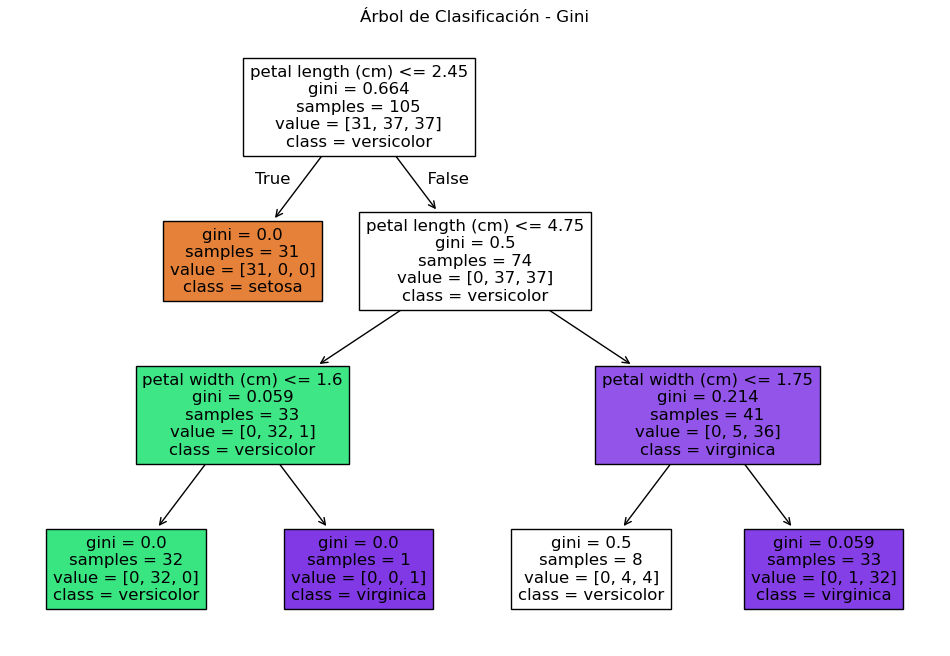

In [24]:
plt.figure(figsize=(12,8))

plot_tree(
    tree_gini,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

plt.title("Árbol de Clasificación - Gini")

plt.show()

#### 2.2 Entropía

In [18]:
tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

tree_entropy.fit(X_train, y_train)

pred_entropy = tree_entropy.predict(X_test)

acc_entropy = accuracy_score(y_test, pred_entropy)

print("Accuracy Entropy:", acc_entropy)

Accuracy Entropy: 0.9777777777777777


**Visualización**

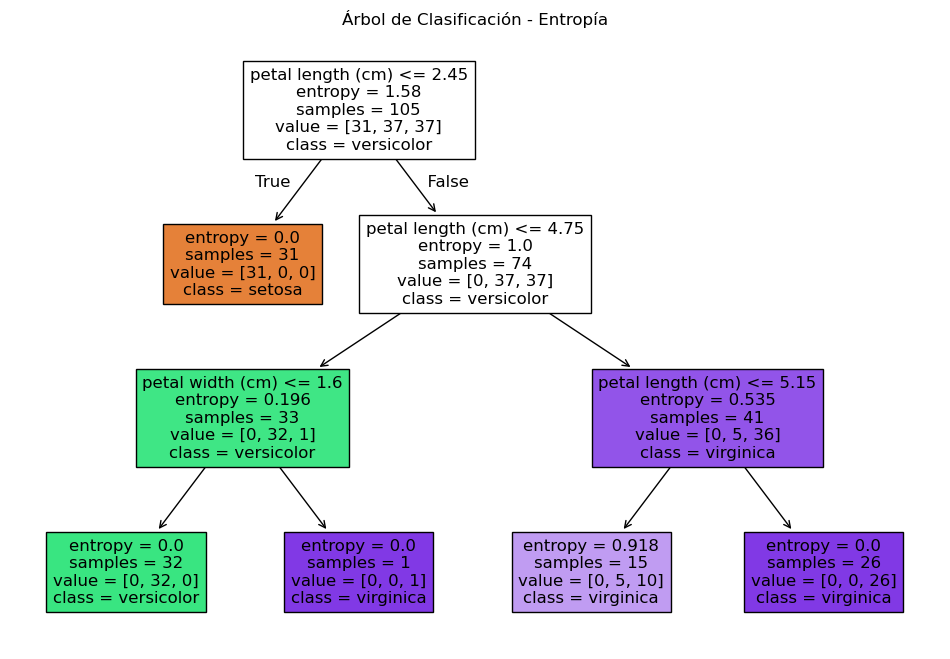

In [19]:
plt.figure(figsize=(12,8))

plot_tree(
    tree_entropy,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

plt.title("Árbol de Clasificación - Entropía")

plt.show()

#### 2.3 Log Loss

In [20]:
tree_log = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=3,
    random_state=42
)

tree_log.fit(X_train, y_train)

pred_log = tree_log.predict(X_test)

acc_log = accuracy_score(y_test, pred_log)

print("Accuracy Log Loss:", acc_log)

Accuracy Log Loss: 0.9777777777777777


**Visualización**

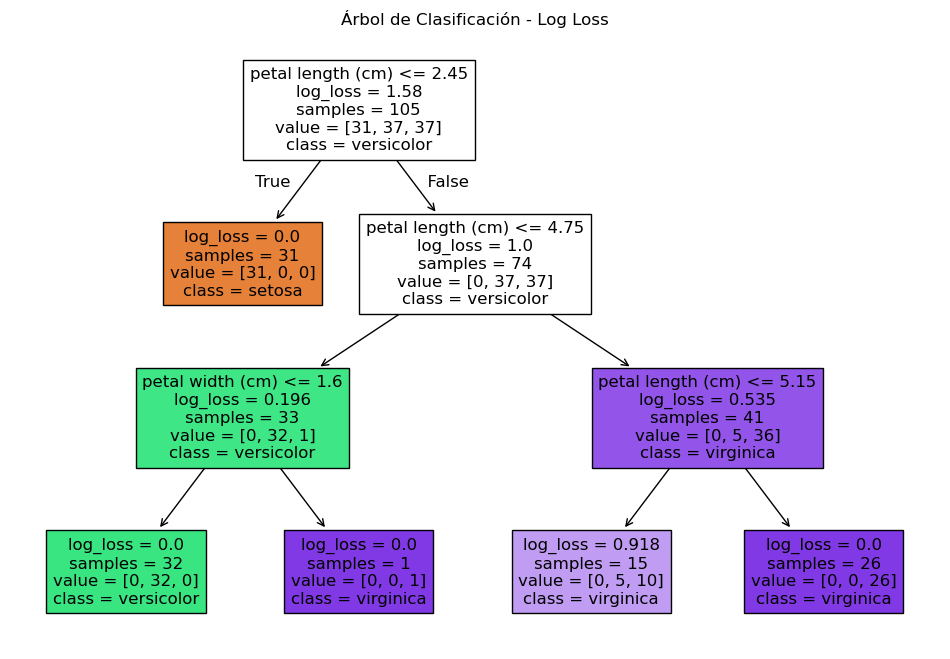

In [21]:
plt.figure(figsize=(12,8))

plot_tree(
    tree_log,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

plt.title("Árbol de Clasificación - Log Loss")

plt.show()

In [23]:
print("Accuracy Gini:", acc_gini)
print("Accuracy Entropy:", acc_entropy)
print("Accuracy Log Loss:", acc_log)

Accuracy Gini: 1.0
Accuracy Entropy: 0.9777777777777777
Accuracy Log Loss: 0.9777777777777777


### Interpretación

El árbol de clasificación utilizando el criterio Gini obtuvo una exactitud del 100%, mientras que los modelos construidos con Entropía y Log Loss obtuvieron una exactitud de aproximadamente 97.78%.

Esto indica que los tres criterios generan modelos con un desempeño muy similar en el dataset Iris, aunque en este caso el criterio Gini produjo el mejor resultado de clasificación.

Además, se observa que los nodos terminales presentan valores de impureza cercanos a cero, lo que significa que las particiones generadas contienen observaciones predominantemente de una sola clase. Esto confirma que los criterios de decisión lograron construir nodos relativamente puros.
_________________

### Conclusiones

Los criterios Gini, Entropía y Log Loss tienen el objetivo de generar particiones más puras en árboles de clasificación. Aunque utilizan fórmulas distintas, los tres buscan reducir la mezcla de clases dentro de cada nodo.

En este ejercicio utilizando el dataset Iris, los tres modelos presentaron un desempeño muy alto debido a que las clases del dataset están bien separadas. El criterio Gini obtuvo la mayor exactitud, aunque las diferencias con Entropía y Log Loss fueron mínimas.

Finalmente, se concluye que tanto Gini como Entropía son criterios muy eficientes para la construcción de árboles de clasificación, mientras que Log Loss incorpora además una penalización probabilística más fuerte ante predicciones incorrectas realizadas con alta confianza.